## Lab Practice Ensemble learning 1.3h:  BAGGING (Homework solution)  | Machine Learning II
#### ESU  Jan-2025
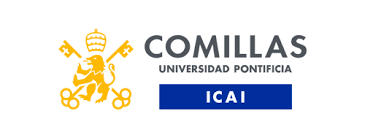

LEARNING OBJECTIVES
- How to apply bagging in classification trees
- Deep understanding of the variability created by boostrap in the ensemble of trees


---
## Import modules

In [20]:
import numpy as np # linear algebra
import pandas as pd  # data management (dataframes)
import matplotlib.pyplot as plt
import seaborn as sns  # plotting

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from sklearn.inspection import permutation_importance

from sklearn.ensemble import BaggingClassifier
#from sklearn.ensemble import BaggingRegressor

# solve problems with size and fonts in figures 
plt.rcParams['figure.dpi'] = 75

# auxiliary functions
import utils_ml1 as uml1
import utils_classification_ml2 as ucml2

### Functions for simplifying workflow with bagged trees

In [21]:
## FUNCIONES

def fit_bagged_tree(number_estimators, Xtr, ytr, INPUTS):

    base_estimator =  Pipeline(steps=[('DT', 
                                        DecisionTreeClassifier( criterion='gini',  # impurity measure
                                                                min_samples_split=2, # Minimum number of obs in node to keep cutting
                                                                min_samples_leaf=1, # Minimum number of obs in a terminal node
                                                                random_state=999))]) # For replication

    ## No hace un grid search, pues ya la estamos pasando number_estimators.
    bag_class_estim = BaggingClassifier(estimator=base_estimator,
                                        n_estimators=number_estimators,
                                        random_state=0)
                        
    # fit the bagged trees
    bag_class_estim.fit(Xtr[INPUTS], ytr)

    return bag_class_estim

def plot_variability_bagged_tree(bag_class_estim):

    # number of nodes in each tree of the ensemble
    node_count_trees = [t['DT'].tree_.node_count for t in bag_class_estim.estimators_]
    mean_number_nodes = np.mean(node_count_trees)

    # number of nodes in each tree of the ensemble
    depth_trees = [t['DT'].tree_.max_depth for t in bag_class_estim.estimators_]
    mean_depth_trees = np.mean(depth_trees)

    fig = plt.figure(figsize=(15, 4))
    ax1=plt.subplot(2,1,1)
    plt.plot(node_count_trees, '.-')
    plt.hlines(mean_number_nodes,0,100, color = 'green', label = f'Mean = {mean_number_nodes}')
    plt.ylabel('Nº of nodes')
    plt.legend()                   
    plt.grid()

    plt.subplot(2,1,2, sharex = ax1)
    plt.plot(depth_trees, '.-')
    plt.hlines(mean_depth_trees,0,100, color = 'red', label = f'Mean = {mean_depth_trees}')
    plt.ylabel('Depth of the tree')                       
    plt.xlabel('Tree of the ensemble') 
    plt.legend()                           
    plt.grid()
    plt.show()

    return

### New functions for grouping mean results

In [22]:
def compute_variability_bagged_tree(bag_class_estim):

    # number of nodes in each tree of the ensemble
    node_count_trees = [t['DT'].tree_.node_count for t in bag_class_estim.estimators_]
    mean_number_nodes = np.mean(node_count_trees)
    std_number_nodes = np.std(node_count_trees)

    # number of nodes in each tree of the ensemble
    depth_trees = [t['DT'].tree_.max_depth for t in bag_class_estim.estimators_]
    mean_depth_trees = np.mean(depth_trees)
    std_depth_trees = np.std(depth_trees)

    dic_mean_var_bagged_tree = {
        'mean_number_nodes': mean_number_nodes,
        'std_number_nodes': std_number_nodes,
        'mean_depth_trees': mean_depth_trees,
        'std_depth_trees': std_depth_trees,
    }

    df_variability = pd.DataFrame([dic_mean_var_bagged_tree])

    return df_variability


from sklearn.utils.multiclass import unique_labels

def compute_errors_bagged_tree(clf, X, y):
  
    # Predict output using the classification model
    y_pred = clf.predict(X)

    # labels (can be less than expected)
    labels = unique_labels(y, y_pred)

    # Compute confusion matrix and obtain main diagonal
    conf_matrix = confusion_matrix(y, y_pred, labels=labels)

    return conf_matrix


In [23]:
def obtain_errors_complexities(inputs, bag_class_estim, X_train, y_train, X_test, y_test):

    df_variability = compute_variability_bagged_tree(bag_class_estim)
    conf_matrix_tr = compute_errors_bagged_tree(bag_class_estim, X_train[inputs], y_train)
    conf_matrix_ts = compute_errors_bagged_tree(bag_class_estim, X_test[inputs], y_test)

    dic_results = {
        'inputs': inputs,
        'mean_number_nodes': df_variability.mean_number_nodes[0],
        'std_number_nodes': df_variability.std_number_nodes[0],
        'mean_depth_trees': df_variability.mean_depth_trees[0],
        'std_depth_trees': df_variability.std_depth_trees[0],
        'train_misclass_01': conf_matrix_tr[0][1],
        'train_misclass_02': conf_matrix_tr[1][0],
        'test_misclass_01': conf_matrix_ts[0][1],
        'test_misclass_10': conf_matrix_ts[1][0],
    }

    df_results = pd.DataFrame([dic_results])

    return df_results

---
## 1. Classification problem

#### 1.1 Load the dataset

In [24]:
# Load file with the dataset
df = pd.read_csv('simDataTriangle.dat', sep = "\t")
print('Dataframe:')
print(df.head())

# Convert output variable to categorical
df.Y = df.Y.astype('category')

Dataframe:
         X1        X2        X3        X4        X5        X6    Y
0 -0.416315  5.704369 -0.520502  5.624744 -0.567509  5.657103  OUT
1 -0.052473  9.467372 -0.308278  9.518659 -0.028233  9.271118  OUT
2 -0.552123  7.329100 -0.563368  7.373105 -0.851291  7.175183  OUT
3  0.290578  7.804284  0.248642  7.461996 -0.038654  7.557059  INS
4  0.116236  7.472282  0.154657  7.231131  0.154816  7.462239  INS


#### 1.3 Split the dataset in TR and TS

In [25]:
# Define input and output matrices
INPUTS = ['X1','X2','X3','X4','X5','X6']
OUTPUT = 'Y'
X = df[INPUTS]
y = df[OUTPUT]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,  #percentage of test data
                                                    random_state=0, #seed for replication
                                                    stratify = y)   #Preserves distribution of y

---
## 2: Fit ensembles of bagged trees using diffent sets of inputs

Six different ensembles are fitted for the same classification problem using the same hyperparameters (gridsearch is not used). The only difference is in the set of inputs variables using for training each ensemble

In [26]:
# Dataframe donde vamos a almacenar los resultados para cada uno de los modelos. 
# Create a dataframe with the main results

df_main_results = pd.DataFrame()

### 2.1: Fit a bagged tree with 100 trees using features X1 and X2

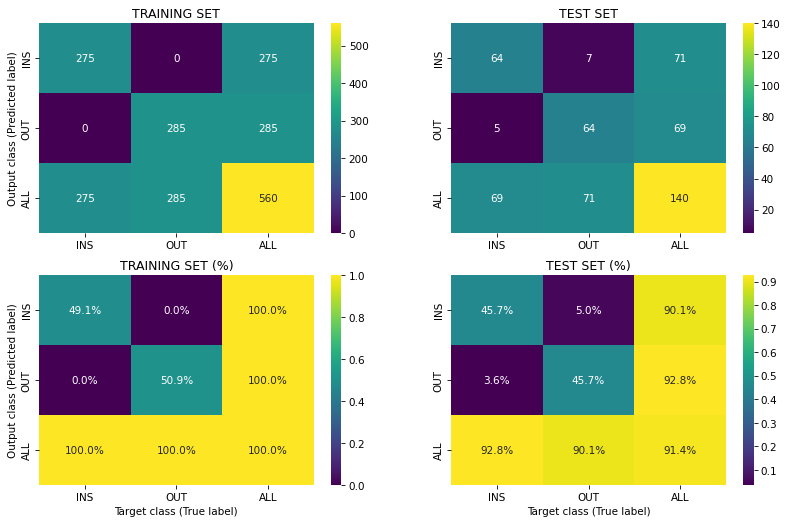

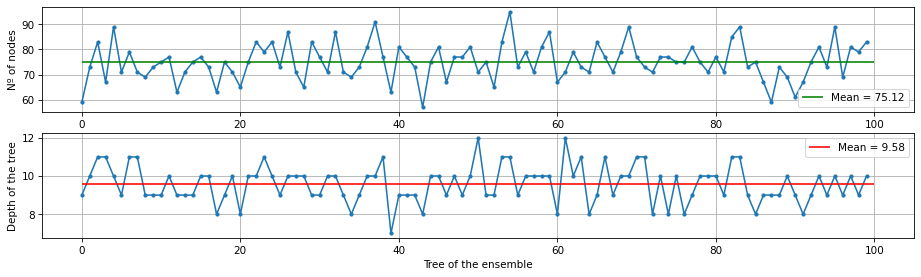

,inputs,mean_number_nodes,std_number_nodes,mean_depth_trees,std_depth_trees,train_misclass_01,train_misclass_02,test_misclass_01,test_misclass_10
0,"[X1, X2]",75.12,7.325681,9.58,0.961041,0,0,5,7


In [27]:
INPUTS_bt_1 = ['X1','X2']
bag_tree_1 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_1)
ucml2.plot_expanded_confusion_matrix(bag_tree_1, X_train[INPUTS_bt_1], y_train, X_test[INPUTS_bt_1], y_test)
plot_variability_bagged_tree(bag_tree_1)

df_main_results = pd.concat([df_main_results,
                             obtain_errors_complexities(INPUTS_bt_1, bag_tree_1, X_train, y_train, X_test, y_test)],
                             ignore_index=True)
df_main_results

### 2.2: Fit a bagged tree with 100 trees using features X1, X2, X3 and X4

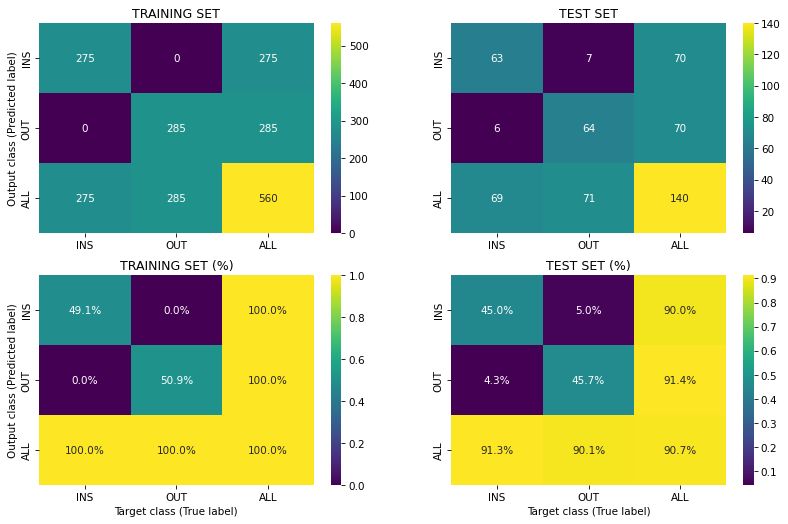

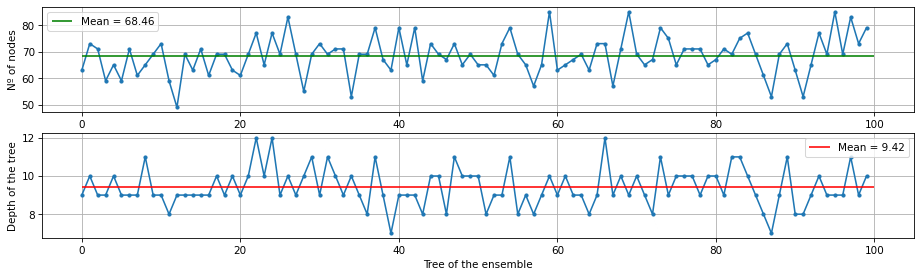

,inputs,mean_number_nodes,std_number_nodes,mean_depth_trees,std_depth_trees,train_misclass_01,train_misclass_02,test_misclass_01,test_misclass_10
0,"[X1, X2]",75.12,7.325681,9.58,0.961041,0,0,5,7
1,"[X1, X2, X3, X4]",68.46,7.160196,9.42,1.001798,0,0,6,7


In [28]:
INPUTS_bt_2 = ['X1','X2','X3','X4']
bag_tree_2 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_2)
ucml2.plot_expanded_confusion_matrix(bag_tree_2, X_train[INPUTS_bt_2], y_train, X_test[INPUTS_bt_2], y_test)
plot_variability_bagged_tree(bag_tree_2)

df_main_results = pd.concat([df_main_results,
                             obtain_errors_complexities(INPUTS_bt_2, bag_tree_2, X_train, y_train, X_test, y_test)],
                             ignore_index=True)
df_main_results

### 2.3: Fit a bagged tree with 100 trees using features X1, X2, X3, X4, X5 and X6

Using ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']


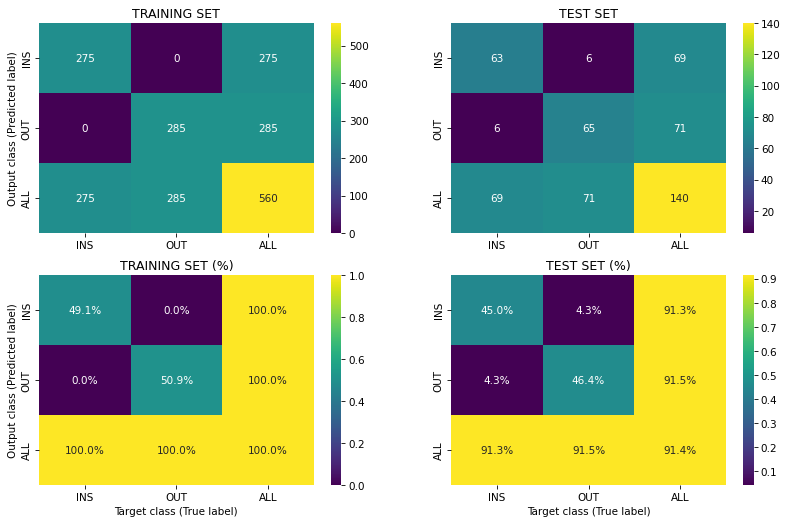

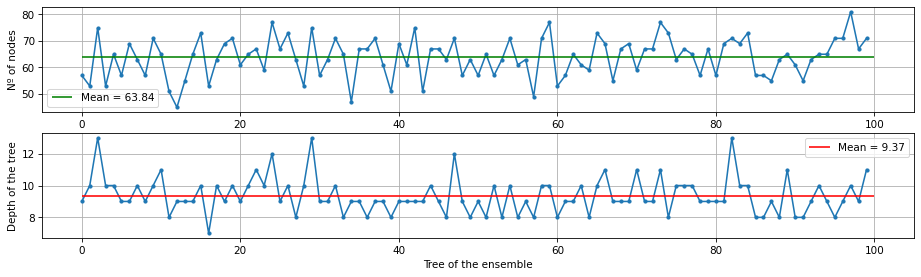

,inputs,mean_number_nodes,std_number_nodes,mean_depth_trees,std_depth_trees,train_misclass_01,train_misclass_02,test_misclass_01,test_misclass_10
0,"[X1, X2]",75.12,7.325681,9.58,0.961041,0,0,5,7
1,"[X1, X2, X3, X4]",68.46,7.160196,9.42,1.001798,0,0,6,7
2,"[X1, X2, X3, X4, X5, X6]",63.84,7.371187,9.37,1.145906,0,0,6,6


In [29]:
INPUTS_bt_3 = ['X1','X2','X3','X4','X5','X6']
bag_tree_3 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_3)
print(f'Using {INPUTS_bt_3}')
ucml2.plot_expanded_confusion_matrix(bag_tree_3, X_train[INPUTS_bt_3], y_train, X_test[INPUTS_bt_3], y_test)
plot_variability_bagged_tree(bag_tree_3)

df_main_results = pd.concat([df_main_results,
                             obtain_errors_complexities(INPUTS_bt_3, bag_tree_3, X_train, y_train, X_test, y_test)],
                             ignore_index=True)
df_main_results

### 2.4: Fit a bagged tree with 100 trees using features X3 and X4

Using ['X3', 'X4']


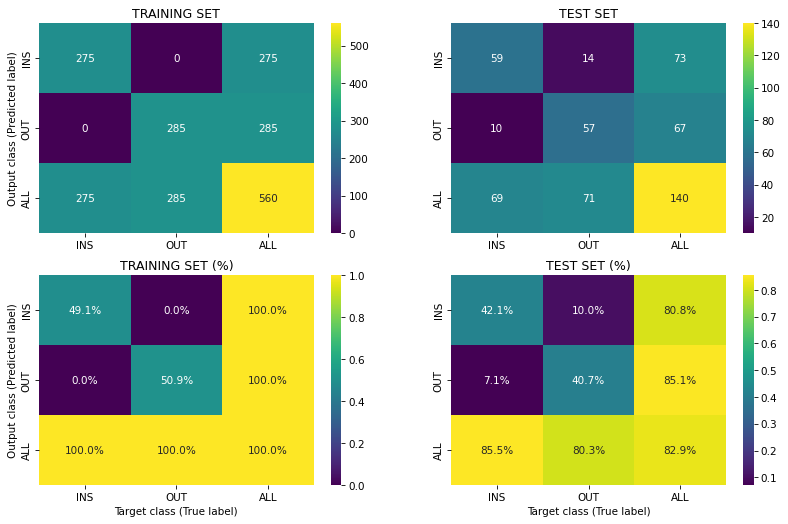

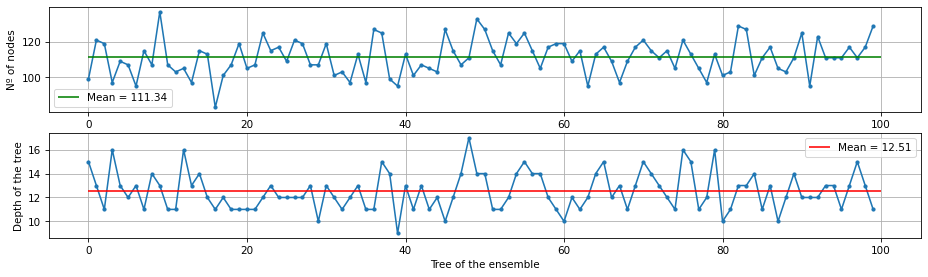

,inputs,mean_number_nodes,std_number_nodes,mean_depth_trees,std_depth_trees,train_misclass_01,train_misclass_02,test_misclass_01,test_misclass_10
0,"[X1, X2]",75.12,7.325681,9.58,0.961041,0,0,5,7
1,"[X1, X2, X3, X4]",68.46,7.160196,9.42,1.001798,0,0,6,7
2,"[X1, X2, X3, X4, X5, X6]",63.84,7.371187,9.37,1.145906,0,0,6,6
3,"[X3, X4]",111.34,9.867340,12.51,1.590566,0,0,10,14


In [30]:
INPUTS_bt_4 = ['X3','X4']
bag_tree_4 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_4)
print(f'Using {INPUTS_bt_4}')
ucml2.plot_expanded_confusion_matrix(bag_tree_4, X_train[INPUTS_bt_4], y_train, X_test[INPUTS_bt_4], y_test)
plot_variability_bagged_tree(bag_tree_4)

df_main_results = pd.concat([df_main_results,
                             obtain_errors_complexities(INPUTS_bt_4, bag_tree_4, X_train, y_train, X_test, y_test)],
                             ignore_index=True)
df_main_results

### 2.5: Fit a bagged tree with 100 trees using features X5 and X6

Using ['X5', 'X6']


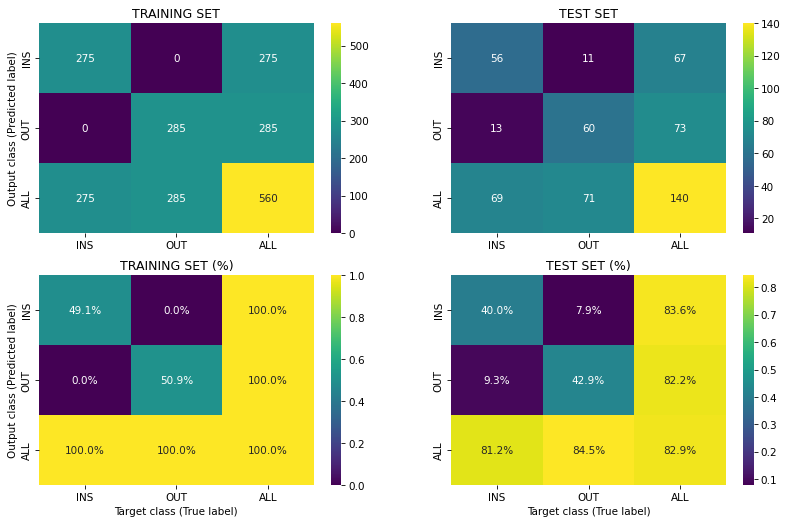

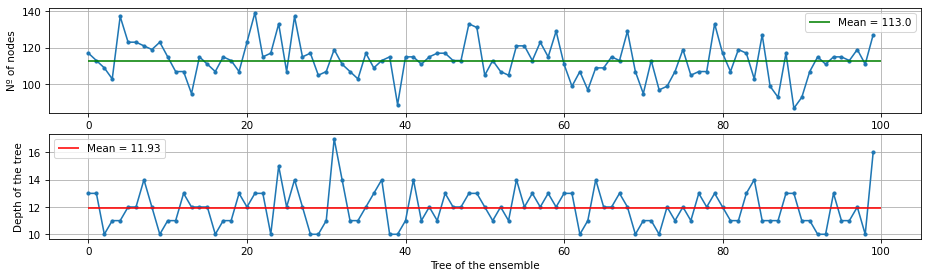

,inputs,mean_number_nodes,std_number_nodes,mean_depth_trees,std_depth_trees,train_misclass_01,train_misclass_02,test_misclass_01,test_misclass_10
0,"[X1, X2]",75.12,7.325681,9.58,0.961041,0,0,5,7
1,"[X1, X2, X3, X4]",68.46,7.160196,9.42,1.001798,0,0,6,7
2,"[X1, X2, X3, X4, X5, X6]",63.84,7.371187,9.37,1.145906,0,0,6,6
3,"[X3, X4]",111.34,9.867340,12.51,1.590566,0,0,10,14
4,"[X5, X6]",113.00,10.154802,11.93,1.365687,0,0,13,11


In [31]:
INPUTS_bt_5 = ['X5', 'X6']
bag_tree_5 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_5)
print(f'Using {INPUTS_bt_5}')
ucml2.plot_expanded_confusion_matrix(bag_tree_5, X_train[INPUTS_bt_5], y_train, X_test[INPUTS_bt_5], y_test)
plot_variability_bagged_tree(bag_tree_5)

df_main_results = pd.concat([df_main_results,
                             obtain_errors_complexities(INPUTS_bt_5, bag_tree_5, X_train, y_train, X_test, y_test)],
                             ignore_index=True)
df_main_results

### 2.6: Fit a bagged tree with 100 trees using features X3, X4, X5 and X6

Using ['X3', 'X4', 'X5', 'X6']


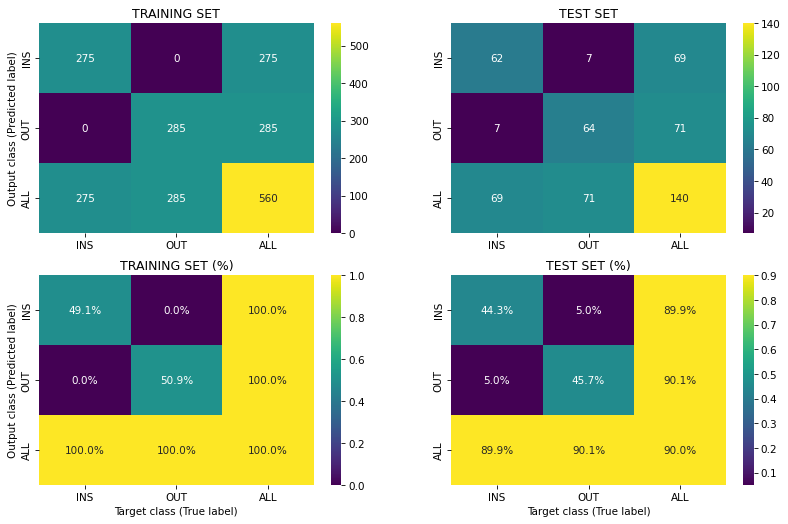

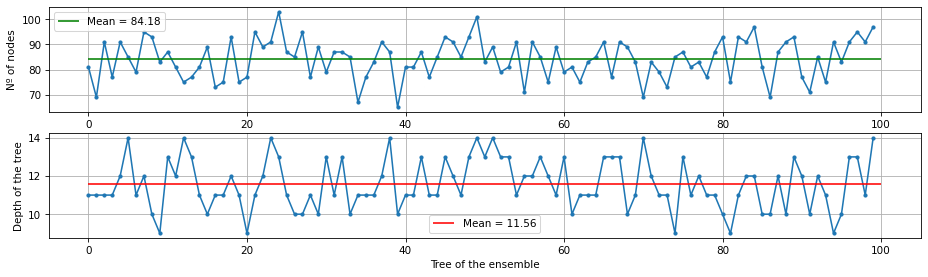

,inputs,mean_number_nodes,std_number_nodes,mean_depth_trees,std_depth_trees,train_misclass_01,train_misclass_02,test_misclass_01,test_misclass_10
0,"[X1, X2]",75.12,7.325681,9.58,0.961041,0,0,5,7
1,"[X1, X2, X3, X4]",68.46,7.160196,9.42,1.001798,0,0,6,7
2,"[X1, X2, X3, X4, X5, X6]",63.84,7.371187,9.37,1.145906,0,0,6,6
3,"[X3, X4]",111.34,9.867340,12.51,1.590566,0,0,10,14
4,"[X5, X6]",113.00,10.154802,11.93,1.365687,0,0,13,11
5,"[X3, X4, X5, X6]",84.18,7.803051,11.56,1.313925,0,0,7,7


In [32]:
INPUTS_bt_6 = ['X3','X4', 'X5','X6']
bag_tree_6 = fit_bagged_tree(number_estimators=100, Xtr=X_train, ytr=y_train, INPUTS = INPUTS_bt_6)
print(f'Using {INPUTS_bt_6}')
ucml2.plot_expanded_confusion_matrix(bag_tree_6, X_train[INPUTS_bt_6], y_train, X_test[INPUTS_bt_6], y_test)
plot_variability_bagged_tree(bag_tree_6)

df_main_results = pd.concat([df_main_results,
                             obtain_errors_complexities(INPUTS_bt_6, bag_tree_6, X_train, y_train, X_test, y_test)],
                             ignore_index=True)
df_main_results

In [16]:
df_main_results.drop(3, inplace=True)  # Elimina la fila en el DataFrame original
df_main_results

,inputs,mean_number_nodes,std_number_nodes,mean_depth_trees,std_depth_trees,train_misclass_01,train_misclass_02,test_misclass_01,test_misclass_10
0,"[X1, X2]",75.12,7.325681,9.58,0.961041,0,0,5,7
1,"[X1, X2, X3, X4]",68.46,7.160196,9.42,1.001798,0,0,6,7
2,"[X1, X2, X3, X4, X5, X6]",63.84,7.371187,9.37,1.145906,0,0,6,6
4,"[X3, X4]",111.34,9.867340,12.51,1.590566,0,0,10,14
5,"[X3, X4, X5, X6]",84.18,7.803051,11.56,1.313925,0,0,7,7


### Questions

Q1. Are there statistically significant differences in the number of nodes and depth of the trees with the ensemble?

Q2. Which bagged tree is the worst in terms of accuracy?

Q4. Which is the best bagged tree?

Q5. Why the complexities of bag_tree_4 and bag_tree_3 are so different?

In [18]:
### Es importante analizar tanto la media como la desviación típica
df_main_results = df_main_results.drop(index=2)
df_main_results

,inputs,mean_number_nodes,std_number_nodes,mean_depth_trees,std_depth_trees,train_misclass_01,train_misclass_02,test_misclass_01,test_misclass_10
0,"[X1, X2]",75.12,7.325681,9.58,0.961041,0,0,5,7
1,"[X1, X2, X3, X4]",68.46,7.160196,9.42,1.001798,0,0,6,7
4,"[X3, X4]",111.34,9.867340,12.51,1.590566,0,0,10,14
5,"[X3, X4, X5, X6]",84.18,7.803051,11.56,1.313925,0,0,7,7


Si para una muestra obtenemos una media con un intervalo de confianza y para otra muestra, un valor de la media muestral por encima pero 
cuyo intervalo de confianza se solapa, entonces se dice que la media es la "misma". 

*Aumentar la profundidad implica aumentar en mucho el numero de nodos.* 

*¿Cuál es mejor proxi para un árbol: la profundidad o el número de nodos?*
- La profundidad es una aproximación burda porque dos árboles con la misma profundidad pueden tener cantidades de nodos muy diferentes.
- El número total de nodos cuantifica directamente la cantidad de divisiones realizadas y, por lo tanto, la complejidad real del árbol.


Un árbol con una rama muy profunda y otra muy superficial implica que hay una serie de datos muy fáciles de separar y otro muy complicada
 

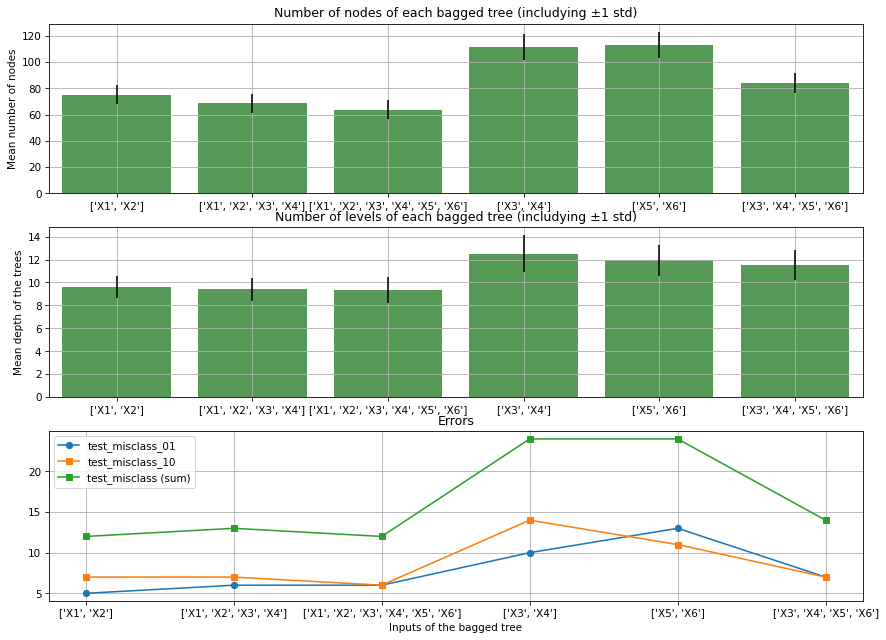

In [33]:
## Pedir los comentarios de esta parte
# plot df_main_results for easy understanding
 
plt.figure(figsize=(14, 10))
    
# mean number of nodes
plt.subplot(3,1,1)
ax = sns.barplot(x=df_main_results["inputs"].astype(str), y=df_main_results["mean_number_nodes"], 
                 yerr=df_main_results["std_number_nodes"], color="green", alpha=0.7)
plt.grid()
plt.xlabel('')
plt.ylabel("Mean number of nodes")
plt.title("Number of nodes of each bagged tree (includying ±1 std)")

# mean depth
plt.subplot(3,1,2)
ax = sns.barplot(x=df_main_results["inputs"].astype(str), y=df_main_results["mean_depth_trees"], 
                 yerr=df_main_results["std_depth_trees"], color="green", alpha=0.7)
plt.grid()
plt.xlabel('')
plt.ylabel("Mean depth of the trees")
plt.title("Number of levels of each bagged tree (includying ±1 std)")

# Errors
plt.subplot(3,1,3)
plt.plot(df_main_results["test_misclass_01"], '-o', label = 'test_misclass_01')
plt.plot(df_main_results["test_misclass_10"], '-s', label = 'test_misclass_10')
plt.plot(df_main_results["test_misclass_01"] + df_main_results["test_misclass_10"], '-s', label = 'test_misclass (sum)')

plt.xticks(range(0,6), df_main_results["inputs"].astype(str))
plt.xlabel("Inputs of the bagged tree")
plt.title('Errors')
plt.grid()
plt.legend()

plt.show()

## podríamos decir que al cuarto arbol le han tocado las variables malas y por eso le cuesta más encontrar los datos, aumentando el número de nodos.
## Trabajando con 3, 4 y 5, 6 por separado obtenemos profundidades, numero de nodos y errores parecidos. Sin emabrgo, al juntar las 4, 
## obtenemos algo que es bastante mejor.

Esta segunda gráfica representa la suma de errores para cada conjunto de variables. Hay que tener en cuenta no solo los errores, si no la variabilidad. Vemos dos modelos muy malos, tres similares (mejores) y uno a medio camino. Entre los similares, deberíamos coger el más simple. En realidad, para analizar esto no deberíamos mirar el número de árboles, si no también la profundidad y la media del número de nodos. 
e
Razonar por qué con [x3,x4] y [x5,x6] sale muy mal y con [x3,x4,x5 y x6] salen bien. --> La razón esta en por que random forest sale tan bien

Q3. why the bag_tree_6 is better than bag_tree_4 and bag_tree_5?

Esto se debe a que para las parejas (X3; X4) y (X5; X6), todos los árboles del bagging van a comenzar por las variables X3 y X5, luego la correlación entre las árboles será alto y, por lo tanto, el error será elevado. Sin embargo, si usamos [X3,X4,X5,X6], algunos árboles empezarán por X3 y otros por X5, dando lugar a menor correlación (y, por tanto, varianza) y, por lo tanto, a menor error.

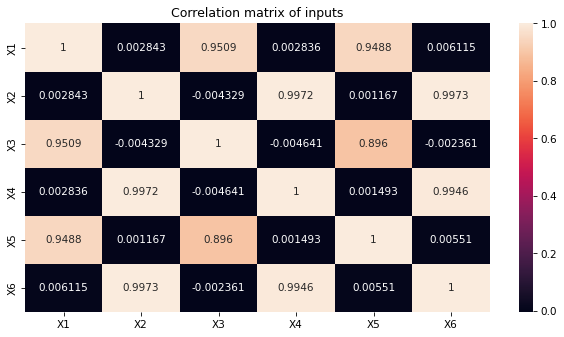

In [34]:
# correlation matrix
mat_corr = df.drop(columns=['Y']).corr()                
fig = plt.figure(1,figsize=(10, 5))
sns.heatmap(mat_corr, annot=True, fmt= ".4g") # si no se ven los textos con demasiadas variables, poner annot=False
plt.title('Correlation matrix of inputs')
plt.show()

## Las impares parece que tienen un poco menos de correlación que las pares.

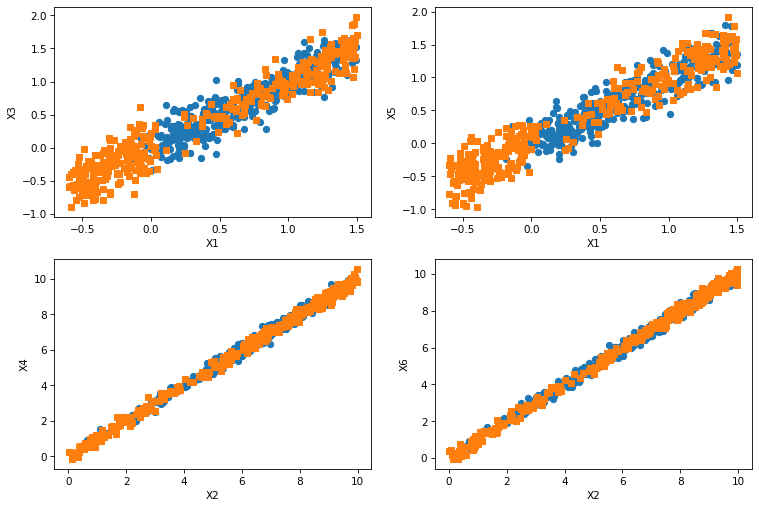

In [35]:
# plot relevant scatterplots
unique_categories = df["Y"].astype('category').cat.codes
legend_labels = dict(enumerate(df["Y"].astype('category').cat.categories))

plt.figure(figsize=(12, 8))
    
# mean number of nodes
plt.subplot(2,2,1)
plt.plot(df.loc[df.Y == 'INS']["X1"], df.loc[df.Y == 'INS']["X3"], 'o')
plt.plot(df.loc[df.Y == 'OUT']["X1"], df.loc[df.Y == 'OUT']["X3"], 's')
plt.xlabel('X1'); plt.ylabel('X3')
plt.subplot(2,2,2)
plt.plot(df.loc[df.Y == 'INS']["X1"], df.loc[df.Y == 'INS']["X5"], 'o')
plt.plot(df.loc[df.Y == 'OUT']["X1"], df.loc[df.Y == 'OUT']["X5"], 's')
plt.xlabel('X1'); plt.ylabel('X5')
plt.subplot(2,2,3)
plt.plot(df.loc[df.Y == 'INS']["X2"], df.loc[df.Y == 'INS']["X4"], 'o')
plt.plot(df.loc[df.Y == 'OUT']["X2"], df.loc[df.Y == 'OUT']["X4"], 's')
plt.xlabel('X2'); plt.ylabel('X4')
plt.subplot(2,2,4)
plt.plot(df.loc[df.Y == 'INS']["X2"], df.loc[df.Y == 'INS']["X6"], 'o')
plt.plot(df.loc[df.Y == 'OUT']["X2"], df.loc[df.Y == 'OUT']["X6"], 's')
plt.xlabel('X2'); plt.ylabel('X6')
plt.show()

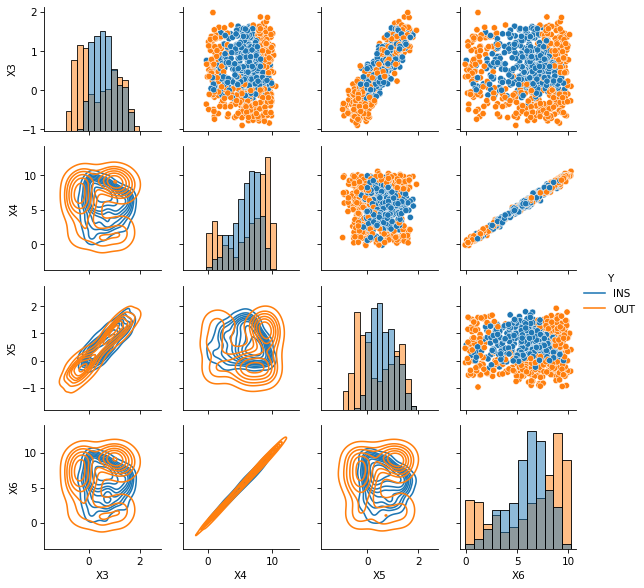

In [36]:
g = sns.PairGrid(df.drop(columns=['X1','X2']), hue="Y", height=2, aspect=1)

g.map_diag(sns.histplot)
#g.map_offdiag(sns.scatterplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.add_legend()